# Lab 1 Case File: Guided Walkthrough

## Goal
In this notebook I want to understand how the original notebook works before trying to improve it.  
I do not want to jump directly into changing things without understanding what is already happening.

## How I am using this notebook
I am opening the original notebook from:

`references/house_price_predictor/house-price-predictor.ipynb`

Then I am reading it section by section and rewriting the logic here in my own words.

This is not the final answers notebook yet.  
This is the notebook where I try to actually understand the case.


## Notebook map

I am inspecting the original notebook in this order:

1. Imports  
2. Loading the CSV  
3. Dataset and split  
4. Model structure  
5. Training process  
6. Testing and metrics  
7. Final graph  
8. Evidence collected

In [1]:
# Optional helper cell
# I can use this cell later if I want to test pieces of the original notebook.

import pandas as pd


# 1. Imports

When I looked at the import section of the original notebook, I noticed that the notebook keeps the setup quite small and focused.  
It imports `csv`, `pandas`, `platform`, `os`, `seaborn`, and `torch`, and then also imports `lightning` as `L`, `torch.utils.data` as `D`, and `torchmetrics` as `M`.

My understanding of the purpose of each one is the following:

- `pandas` is used to load and work with the CSV data.
- `torch` is the main deep learning library used to create tensors and build the neural network.
- `torch.utils.data` is used for dataset tools such as `TensorDataset` and splitting the data.
- `lightning` is used to organize training more cleanly through things like `LightningModule`, `LightningDataModule`, and `Trainer`.
- `torchmetrics` is used for evaluation metrics, in this case R².
- `seaborn` is used for the final visualization of predictions versus real values.
- `os` is used to access files such as the training log CSV.
- `platform` is only used to print the Python version.
- `csv` is imported, although in practice the notebook mainly works through `pandas.read_csv`.

So already from the imports I can see the overall flow of the notebook:
first load data, then turn it into tensors, then define a model, then train it with Lightning, then evaluate it, and finally visualize the predictions.

The imports are basically the toolbox.  
Some tools are for reading the table, some are for building the model, some are for training it, and some are for drawing the final graph.

### My mental map
- **Table / data tools**: `pandas`
- **Deep learning tools**: `torch`
- **Training organization**: `lightning`
- **Metrics / judging the suspect**: `torchmetrics`
- **Plotting / visual evidence**: `seaborn`

This makes the notebook feel less random.  
Instead of seeing a scary wall of imports, I can see the job of each tool.

# 2. Loading the CSV

The data used in the notebook comes from `BostonHousing.csv`, which is included in the repository itself.  
That is useful because I do not need to download anything separately.

When I looked at the sample output, I could see that each row represents one house and each column is a feature of that house.  
The notebook explains that the last column is the target and all previous columns are features.  
The target column is `medv`, which represents the house price in thousands of dollars.

So the structure is basically this:
- one row = one house
- first 13 columns = clues about the house
- last column = the price we want to predict

The notebook loads the CSV into a pandas DataFrame and then later converts the values into tensors.  
That is an important bridge: first the data exists as a table, then it gets transformed into something the neural network can understand.

I also noticed that the notebook samples five rows from the DataFrame to let us visually inspect the data before training.  
I like this because it reminds me that before touching the model, I should first look at the evidence.

## Optional visual experiment: look at the raw case file

Here I want to visually inspect the dataset before caring about the model.

The goal is to answer simple questions:
- How big is the dataset?
- What does one row look like?
- What does the target column look like?
- Does the target already look nicely balanced or not?

This is useful because if the data already looks weird, the model’s behavior later will make more sense.

CSV path: ..\..\references\house_price_predictor\BostonHousing.csv
Shape: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


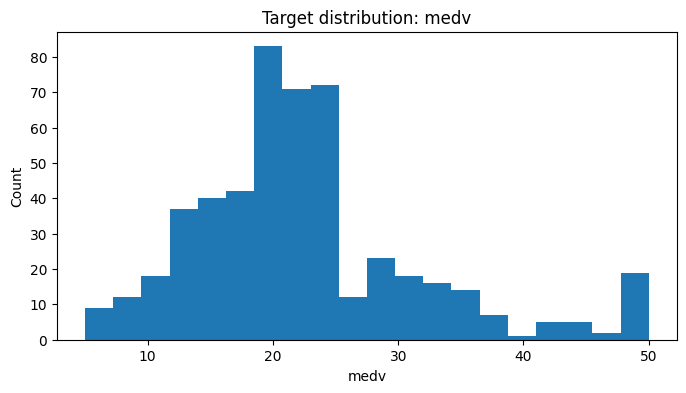

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

possible_paths = [
    Path("../../references/house_price_predictor/BostonHousing.csv"),
    Path("references/house_price_predictor/BostonHousing.csv"),
    Path("BostonHousing.csv"),
]

csv_path = None
for p in possible_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("BostonHousing.csv was not found. Check the notebook location.")

df = pd.read_csv(csv_path)
print("CSV path:", csv_path)
print("Shape:", df.shape)
display(df.head())

plt.figure(figsize=(8, 4))
plt.hist(df["medv"], bins=20)
plt.xlabel("medv")
plt.ylabel("Count")
plt.title("Target distribution: medv")
plt.show()


# 3. Dataset and split

After loading the DataFrame, the notebook creates a custom class called `TabularDataset` that inherits from `TensorDataset`.

What this class does is simple but important:
it takes the pandas DataFrame, converts all rows to floats, turns them into a PyTorch tensor, and then splits the tensor into:
- features: all columns except the last one
- target: the last column

That means the notebook is making a very clear assumption:
the final column is always the answer and everything before it is input information.

The method `num_features()` is also useful because it tells the model how many input values each house has.  
In this case, it reports 13 features.

After that, the notebook splits the dataset into three parts using `random_split`:
- 60% train
- 30% validation
- 10% test

In numbers, the original sample output shows:
- 304 training items
- 152 validation items
- 50 test items

Then these three sets are placed inside a Lightning DataModule.

This part is important for me because it shows the pipeline:
CSV -> DataFrame -> TensorDataset -> split datasets -> DataModule -> DataLoaders

Why is the split useful?

The training set is where the model learns patterns.  
The validation set is where we check during training whether it is improving or starting to stagnate.  
The test set is the final honest check at the end.

So the notebook is not only building a model.  
It is also trying to create a fair system to judge the model.

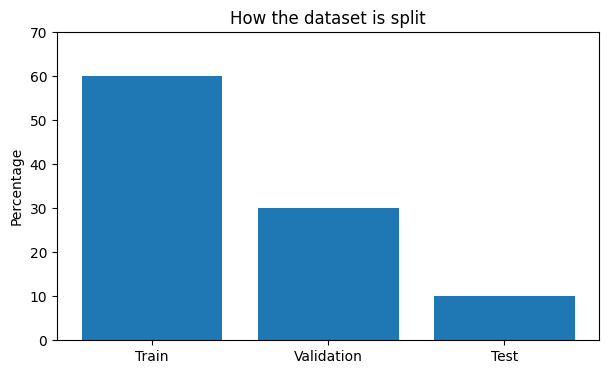

In [3]:
import matplotlib.pyplot as plt

split_names = ["Train", "Validation", "Test"]
split_values = [60, 30, 10]

plt.figure(figsize=(7, 4))
plt.bar(split_names, split_values)
plt.ylabel("Percentage")
plt.title("How the dataset is split")
plt.ylim(0, 70)
plt.show()


# 4. Model structure

The model used in the notebook is a simple feedforward neural network.

Inside the `RegressionModel` class, the network is defined with `nn.Sequential` and has this structure:

- first linear layer: from 13 input features to 64 hidden units
- ReLU activation
- second linear layer: from 64 hidden units to 1 output

This means the model takes 13 numeric values describing a house, processes them through one hidden layer, and outputs one single number.

That single output is exactly why this is a regression task and not a classification task.  
In classification, the model would usually output probabilities or class scores.  
Here it outputs one continuous value, which is the predicted house price.

The model also defines:
- `MSELoss()` as the loss function
- `R2Score()` as a metric
- `Adam` as the optimizer with learning rate `0.001`

I would not call this the most advanced house-price model in the world, but I think that is the point.  
The structure is intentionally simple so that a beginner can still follow what is happening.

One thing I found useful is that the `forward()` method returns `self.model(x).view(-1)`.  
This reshapes the output into a one-dimensional format, which is convenient for comparing predictions with the true target values.

## Visual explanation: what goes through the model

Sometimes the code for the model looks shorter than the idea behind it, so I wanted a tiny diagram.

### My mental picture

`13 house features -> hidden layer of 64 neurons -> ReLU -> 1 predicted price`

This means:
- the model reads 13 numeric clues
- it transforms them in the hidden layer
- ReLU adds non-linearity, so the model is not stuck behaving like a completely straight line
- the final output is one number because the task is regression

In [4]:
# Optional tiny experiment:
# changing the hidden size changes how many parameters the model has.

def parameter_count(input_size, hidden_size, output_size=1):
    first_layer = input_size * hidden_size + hidden_size
    second_layer = hidden_size * output_size + output_size
    return first_layer + second_layer

for hidden in [8, 16, 32, 64, 128]:
    print(f"Hidden size {hidden:>3} -> parameters: {parameter_count(13, hidden)}")


Hidden size   8 -> parameters: 121
Hidden size  16 -> parameters: 241
Hidden size  32 -> parameters: 481
Hidden size  64 -> parameters: 961
Hidden size 128 -> parameters: 1921


### What I learn from changing the hidden size
If I increase the hidden layer, the model gets more capacity.  
That can help it learn more complex patterns, but it can also make it easier to overfit.

# 5. Training process

The training logic is contained in the `LightningModule`.

During `training_step`, the model receives a batch of houses and the real prices.  
It predicts prices and computes the loss using mean squared error.

During `validation_step`, it does the same thing but instead of returning the training loss, it logs `val_loss`.  
This is important because the notebook uses validation loss as the signal for deciding when to stop training.

The optimizer is Adam with learning rate `0.001`.  
My understanding is that the learning rate controls how big each update step is when the model tries to improve itself.  
If the learning rate is too high, the model can jump around too much.  
If it is too low, training can become very slow.

The notebook then creates a Lightning `Trainer` and uses early stopping based on `val_loss`.

This means the model trains for epochs, and after each epoch the validation loss is checked.  
If the validation loss no longer improves, training is stopped.  
This is useful because there is no point in forcing the model to keep doing reps if it has already stopped getting better.

The notebook also reads the metrics log from the trainer folder and plots the validation loss per epoch.  
That is a nice touch because it gives visual proof that training eventually flattens out.

For me, the key idea here is:
- Training is not just “run model until tired.” 
- Training is “watch performance and stop when extra training is no longer helping.”

## Optional visual experiment: how MSE reacts when predictions get worse

Since the notebook uses rooted mean squared error, I wanted a tiny toy example to feel what that loss is doing.

The point is simple:
- small mistakes give small penalties
- big mistakes get punished much more because the error is squared


Good prediction MSE: 1.6
Bad prediction MSE : 341.0


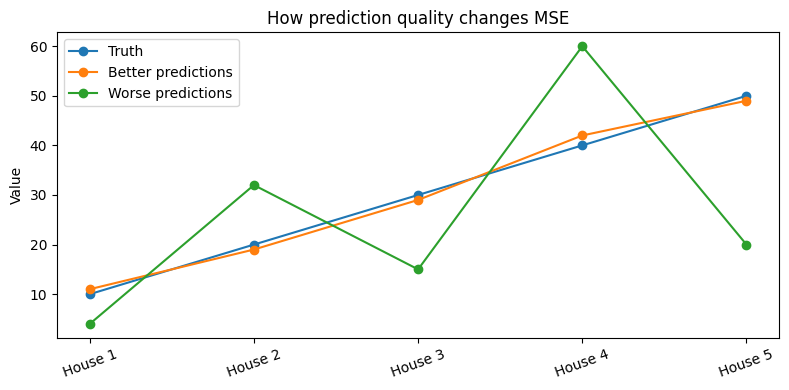

In [5]:
import numpy as np
import matplotlib.pyplot as plt

truth = np.array([10, 20, 30, 40, 50])
good_predictions = np.array([11, 19, 29, 42, 49])
bad_predictions = np.array([4, 32, 15, 60, 20])

good_sq_error = (truth - good_predictions) ** 2
bad_sq_error = (truth - bad_predictions) ** 2

print("Good prediction MSE:", good_sq_error.mean())
print("Bad prediction MSE :", bad_sq_error.mean())

x = np.arange(len(truth))

plt.figure(figsize=(8, 4))
plt.plot(x, truth, marker="o", label="Truth")
plt.plot(x, good_predictions, marker="o", label="Better predictions")
plt.plot(x, bad_predictions, marker="o", label="Worse predictions")
plt.xticks(x, [f"House {i+1}" for i in x], rotation=20)
plt.ylabel("Value")
plt.title("How prediction quality changes MSE")
plt.legend()
plt.tight_layout()
plt.show()


MSE is not just checking whether a prediction is wrong.  
It is checking **how wrong** it is, and it punishes big misses harder.

# 6. Testing and metrics

After training, the notebook runs the model on the test data.  
This is the part that matters most for judging the model honestly, because the test set is supposed to represent unseen data.

The original notebook already calculates and logs `test_r2`.  
That was interesting for me because one of the improvement ideas in the README mentions R², but the notebook already includes it in the testing step.  
So the real missing part is not the complete absence of R², but rather a stronger explanation of it and the addition of RMSE.

In the sample output of the original notebook, the reported test R² is about `0.6255`.

My interpretation of that value is:
the model is doing decently, but not amazingly.  
It is clearly learning something useful from the features, because the score is much better than `0`, but it is also far from `1`, so it is not capturing the full pattern of house prices.

In simple terms, the model understands a reasonable portion of the house-price pattern, but there is still a lot of variance it does not explain.

I also noticed that the test step only logs R².  
It does not calculate RMSE, even though RMSE would be very useful because it would tell me the average size of the prediction error in the same unit as the target.

That means this section is already half good:
- it does evaluate the model
- but it still lacks a second metric that is easier to interpret in real-price terms

So R² tells me how much of the price pattern the model understood.  
A score around `0.6255` tells me the model is not clueless, but it is also not some all-knowing housing prophet.

## Optional visual experiment: R² and RMSE in a tiny example

I wanted a small example to make the metrics feel less abstract.

The idea is:
- R² tells me how well the predictions follow the pattern
- RMSE tells me the typical size of the prediction error in the same unit as the target


Better predictions -> R²: 0.9921, RMSE: 1.0000
Worse predictions -> R²: -1.1778, RMSE: 16.6132


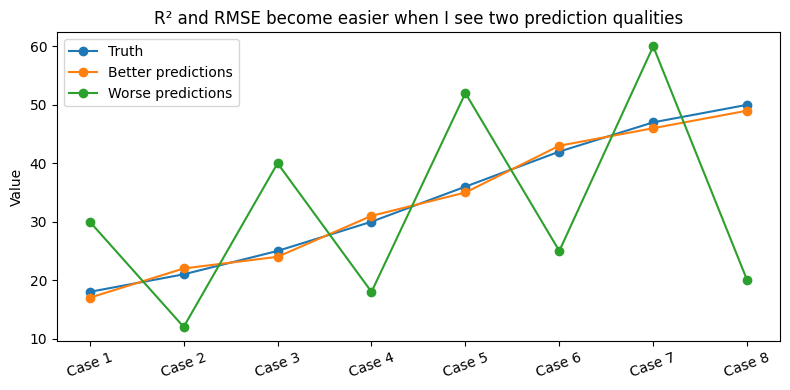

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error

truth = np.array([18, 21, 25, 30, 36, 42, 47, 50])
better_predictions = np.array([17, 22, 24, 31, 35, 43, 46, 49])
worse_predictions = np.array([30, 12, 40, 18, 52, 25, 60, 20])

for name, preds in [("Better", better_predictions), ("Worse", worse_predictions)]:
    r2 = r2_score(truth, preds)
    rmse = root_mean_squared_error(truth, preds)
    print(f"{name} predictions -> R²: {r2:.4f}, RMSE: {rmse:.4f}")

x = np.arange(len(truth))
plt.figure(figsize=(8, 4))
plt.plot(x, truth, marker="o", label="Truth")
plt.plot(x, better_predictions, marker="o", label="Better predictions")
plt.plot(x, worse_predictions, marker="o", label="Worse predictions")
plt.xticks(x, [f"Case {i+1}" for i in x], rotation=20)
plt.ylabel("Value")
plt.title("R² and RMSE become easier when I see two prediction qualities")
plt.legend()
plt.tight_layout()
plt.show()


### What this helps me understand
A better model should usually have:
- a **higher** R²
- a **lower** RMSE

So the two metrics complement each other:
one checks pattern understanding, the other checks typical mistake size.

# 7. Final graph

At the end, the notebook creates a DataFrame with two columns:
- `truth`
- `prediction`

Then it plots them using `seaborn.regplot`.

This graph helps compare predicted prices against the real prices.  
If the predictions were perfect, I would expect the dots to lie very close to a clean straight-line pattern.

The notebook explains that dots close to the line are good predictions and dots scattered away from the line represent larger errors.  
I agree with that interpretation.

What I found especially interesting is the observation made in the notebook itself:
the model seems to do reasonably well for houses in the middle price range, but it does worse for very cheap or very expensive houses.

When I looked at the table of truth, prediction, and absolute error, this made sense.  
Some of the largest errors happen on more extreme values, such as houses with real price `50.0` being predicted much lower.  
So the model seems better at normal cases than at the extremes.

The notebook also adds an `error` column and prints the table.  
That is useful, but I still think the visualization could be improved.

A stronger follow-up would be:
- a histogram of the errors
- a residual plot
- maybe a bar chart of the largest prediction mistakes

So I would say the final graph is helpful, but not enough by itself.  
It shows alignment between truth and prediction, but it does not fully expose how the errors are distributed.


In summary the final graph checks whether the model’s guesses line up with reality.  
If the dots hug the line, the model is behaving.  
If the dots fly away from the line, the model is guessing like a drunk fortune teller.


## Optional visual experiment: residual errors

The final graph in the original notebook compares truth and prediction, which is useful.  
But I also want a residual view because it makes the mistakes easier to inspect.

Residual = `truth - prediction`

If the residuals are centered around zero with no obvious pattern, that is a healthier sign.  
If they show structure, then the model is still missing something systematic.


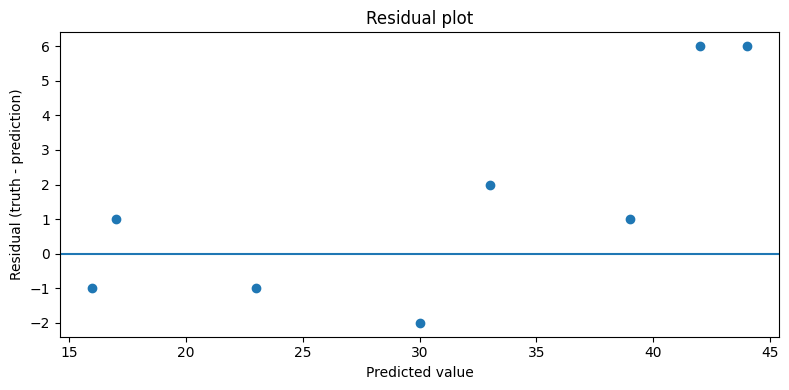

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Example only:
# Replace these arrays with the real values later if I want to.
truth = np.array([15, 18, 22, 28, 35, 40, 48, 50])
prediction = np.array([16, 17, 23, 30, 33, 39, 42, 44])

residuals = truth - prediction

plt.figure(figsize=(8, 4))
plt.axhline(0)
plt.scatter(prediction, residuals)
plt.xlabel("Predicted value")
plt.ylabel("Residual (truth - prediction)")
plt.title("Residual plot")
plt.tight_layout()
plt.show()


That matters for this lab because one of the improvement questions is about better error analysis.

# 8. Evidence collected

In this section I collect the key facts from the notebook because I will need them later in the final answers notebook.

## Case evidence

- Dataset used: `BostonHousing.csv`
- Type of task: regression
- What one row represents: one house
- Number of input features: 13
- Target variable: `medv`
- Meaning of target: house price in thousands of dollars
- Train split: 60%
- Validation split: 30%
- Test split: 10%
- Sample split sizes shown in the notebook: 304 train, 152 validation, 50 test
- Model type: simple feedforward neural network
- Main architecture: Linear(13 -> 64) -> ReLU -> Linear(64 -> 1)
- Activation function: ReLU
- Loss function: mean squared error
- Optimizer: Adam
- Learning rate: 0.001
- Existing evaluation metric: R²
- Sample test R² shown in the notebook: about 0.6255
- Existing final visualization: regplot of truth vs prediction
- Extra thing already shown at the end: table of truth, prediction, and absolute error
- Missing evaluation metric: RMSE
- Missing improvement idea 1: clearer error visualization
- Missing improvement idea 2: interpret R² and RMSE in relation to the case
- Missing improvement idea 3: inspect whether the data is normally distributed and discuss what can be done if it is not

At this stage, I think the original notebook does a good job as a starting point.  
It is clear, small, and beginner-friendly.

However, it still leaves three important areas open:
1. stronger error analysis
2. fuller metric interpretation
3. discussion of data distribution and possible preprocessing improvements